# Week 6 — Final AI/ML Project

## Customer Churn Prediction Using Machine Learning
 
**Week:** 6  
**Assignment:** Final Project

---

## Project Objective

The objective of this final project is to develop a complete Artificial Intelligence and Machine Learning solution for predicting customer churn.

The project demonstrates the complete machine learning workflow:

**Problem Definition → Data Collection → Data Cleaning → Data Analysis → Model Development → Training → Prediction → Evaluation → Conclusion**

A customer churn prediction system can help businesses identify customers who are likely to leave their service and take appropriate retention actions.

# Task 1 — Project Selection & Problem Statement

## Project Title

**Customer Churn Prediction Using Machine Learning**

## Problem Statement

Customer churn refers to the situation where a customer stops using a company's products or services.

Customer retention is important because acquiring new customers can be more expensive than retaining existing customers. Therefore, businesses need effective methods to identify customers who are likely to churn.

The objective of this project is to develop a machine learning model that can predict whether a customer is likely to churn based on customer information, service details, account information, and billing characteristics.

## Objective

The main objectives of this project are:

1. Collect and understand a customer churn dataset.
2. Clean and preprocess the dataset.
3. Perform exploratory data analysis.
4. Identify patterns and factors related to customer churn.
5. Develop a machine learning classification model.
6. Generate churn predictions for unseen customers.
7. Evaluate the model using classification metrics.
8. Identify possible improvements and real-world applications.

## Why AI/ML is Suitable

Machine learning is suitable for this problem because customer churn depends on multiple factors that may interact with each other.

A machine learning model can learn patterns from historical customer data and use those patterns to predict whether new customers are likely to churn.

This can help businesses make data-driven customer retention decisions.

## Expected Outcome

The expected outcome is a trained classification model capable of predicting customer churn with good accuracy and identifying patterns associated with customers who leave a service.

## Real-World Application

A churn prediction system can be used by:

- Telecommunications companies
- Banks and financial institutions
- Subscription-based services
- E-commerce platforms
- Internet service providers
- SaaS companies

Businesses can use churn predictions to identify high-risk customers and design targeted retention strategies.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


# Task 2 — Data Collection & Data Preprocessing

## Dataset Description

The dataset contains customer information from a telecommunications service provider.

Each row represents one customer, while the columns contain information about the customer's demographic characteristics, services, account information, and churn status.

The target variable is **Churn**, which indicates whether the customer left the service.

Important features include:

- Gender
- Senior Citizen status
- Partner
- Dependents
- Tenure
- Phone Service
- Internet Service
- Contract
- Payment Method
- Monthly Charges
- Total Charges
- Churn

The dataset will be analyzed and cleaned before being used to train the machine learning model.

In [6]:
df = pd.read_csv("Dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 7043
Number of columns: 21


## 2. Display First Records

The first few records are displayed to understand the structure and contents of the dataset.

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Display Last Records

The last few records are displayed to verify the dataset structure and ensure that the data has been loaded completely.

In [8]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## 4. Dataset Dimensions

The shape of the dataset provides the total number of observations and features.

The number of rows represents the number of customers, while the number of columns represents the available variables.

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


## 5. Data Types

Examining data types is important because machine learning algorithms require numerical input.

Categorical variables will need to be converted into numerical representations during preprocessing.

In [10]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

## 6. Missing Value Analysis

Missing values can negatively affect machine learning models.

Therefore, the dataset is checked for missing values before preprocessing.

In [11]:
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 7. Duplicate Record Analysis

Duplicate records can introduce bias into the analysis and training process.

The dataset is checked for duplicate rows before model development.

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 8. Data Cleaning

The `TotalCharges` feature should represent a numerical monetary value. However, some records may contain blank strings.

These blank values will first be converted into missing values and then handled appropriately.

The `customerID` column is an identifier and does not provide useful predictive information, so it will be removed before model training.

In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion:
11


In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [15]:
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

print("customerID removed successfully.")
print("Current number of columns:", df.shape[1])

customerID removed successfully.
Current number of columns: 20


## 9. Save Cleaned Dataset

After handling missing values, removing duplicates, and removing the customer identifier, the cleaned dataset is saved for future use.

In [16]:
df.to_csv("Cleaned_Dataset.csv", index=False)

print("Cleaned_Dataset.csv saved successfully!")

Cleaned_Dataset.csv saved successfully!


## 10. Target Variable

The target variable for this project is **Churn**.

It contains two possible classes:

- Yes — Customer churned
- No — Customer remained with the company

This makes the problem a **binary classification problem**.

In [17]:
print("Target variable:")
print(df["Churn"].value_counts())

Target variable:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## 11. Feature Selection

The features are the variables used by the machine learning model to predict customer churn.

The target variable `Churn` is separated from the input features.

Categorical variables will later be converted into numerical values using encoding techniques.

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


# Task 3 — Data Analysis & Visualization

## 1. Churn Distribution

The first step in exploratory data analysis is to understand the distribution of the target variable.

The `Churn` variable indicates whether a customer has left the company.

This visualization helps us determine whether the dataset contains a balanced distribution of churned and non-churned customers.

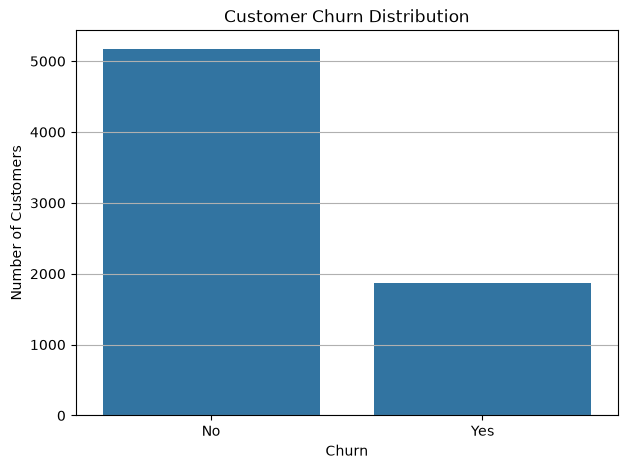

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.grid(axis="y")

plt.savefig(
    "Screenshots/Task3_Churn_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The churn distribution shows that customers who did not churn represent a larger proportion of the dataset than customers who churned.

This indicates that the dataset is somewhat imbalanced. Therefore, accuracy alone should not be used to judge the model's performance. Precision, recall, F1-score, and the confusion matrix will also be considered during model evaluation.

## 2. Churn by Contract Type

Contract type may have an important relationship with customer retention.

Customers with different contract durations may have different probabilities of leaving the service.

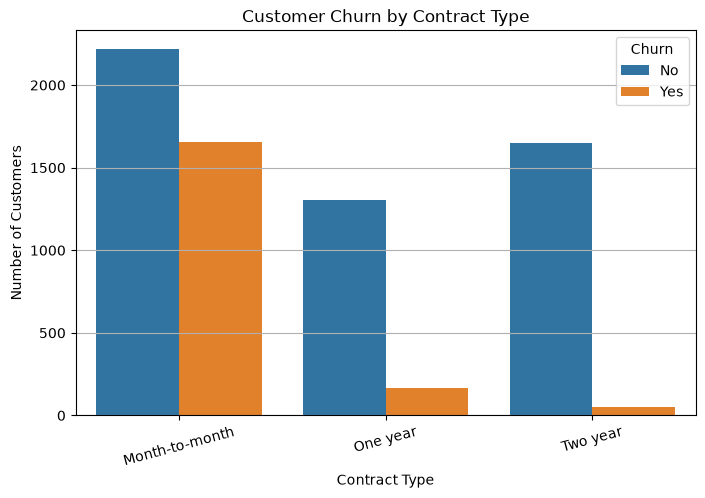

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.grid(axis="y")

plt.savefig(
    "Screenshots/Task3_Churn_by_Contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The visualization shows that customers with month-to-month contracts generally have a higher number of churned customers compared with customers on longer-term contracts.

Longer contracts appear to be associated with better customer retention. This suggests that contract type may be an important predictive feature for churn.


## 3. Churn by Customer Tenure

Tenure represents the number of months a customer has remained with the company.

Analyzing tenure can help determine whether newer or long-term customers are more likely to churn.

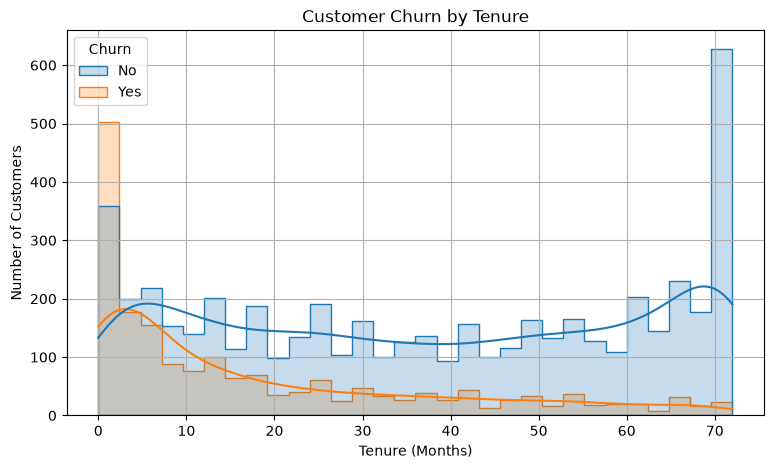

In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.grid(True)

plt.savefig(
    "Screenshots/Task3_Churn_by_Tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The tenure distribution indicates that customers with shorter relationships with the company tend to show a greater likelihood of churn.

Customers with longer tenure generally appear more stable. This suggests that customer retention is particularly important during the early stages of the customer relationship.

## 4. Monthly Charges and Churn

Monthly charges represent the amount a customer is charged each month.

Analyzing this feature can help determine whether customers with higher monthly charges show different churn behavior.

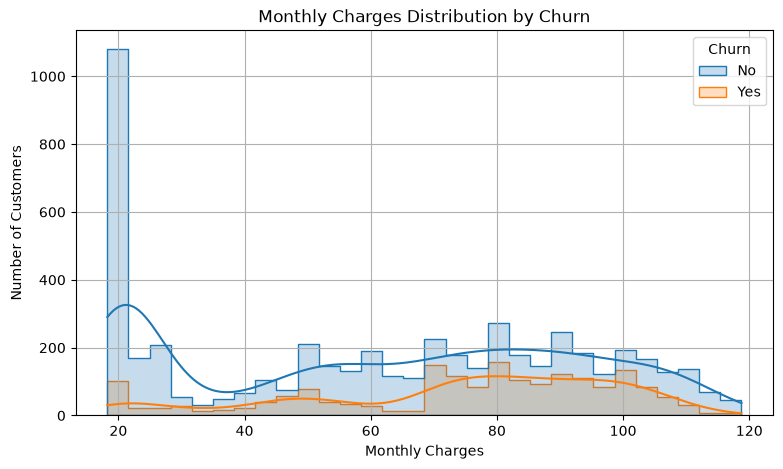

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.grid(True)

plt.savefig(
    "Screenshots/Task3_Monthly_Charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The distribution suggests that churn behavior varies across different monthly charge levels.

Customers with relatively higher monthly charges can show greater churn in some ranges. This indicates that pricing and service costs may be relevant factors when predicting customer churn.

## 5. Correlation Heatmap

A correlation heatmap is used to examine relationships between numerical variables.

Correlation values range from -1 to +1:

- +1 indicates a strong positive relationship.
- -1 indicates a strong negative relationship.
- 0 indicates little or no linear relationship.

The heatmap helps identify potentially important relationships between numerical features.

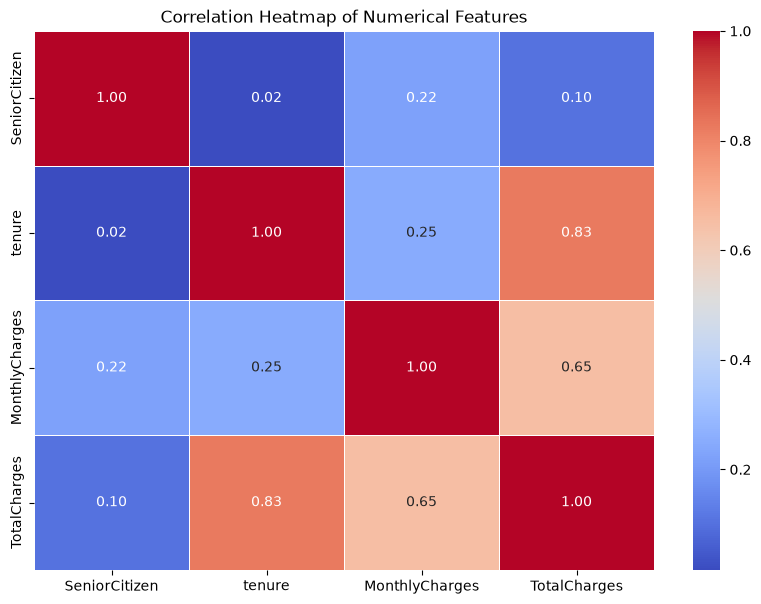

In [24]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.savefig(
    "Screenshots/Task3_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The correlation heatmap shows the relationships between the numerical features in the dataset.

Tenure and total charges generally have a positive relationship because customers who stay longer tend to accumulate higher total charges.

The heatmap also helps identify features that may contain useful information for predicting customer churn. However, correlation alone does not determine whether a feature should be included or excluded from a machine learning model.

## Task 3 — EDA Summary

The exploratory data analysis provided several useful observations about customer churn.

1. The dataset contains more non-churned customers than churned customers.
2. Month-to-month contracts appear to have a higher churn rate than longer-term contracts.
3. Customers with shorter tenure tend to show higher churn behavior.
4. Monthly charges appear to have a relationship with customer churn.
5. The correlation heatmap provides an overview of relationships between numerical features.

These observations will help guide the model development stage. The machine learning model will use multiple customer characteristics simultaneously rather than relying on a single feature.

# Task 4 — Model Development & Training

## 1. Selected Machine Learning Algorithm

### Random Forest Classifier

For this project, a **Random Forest Classifier** is selected to predict customer churn.

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to produce a more reliable prediction.

### Why Random Forest is Suitable

Random Forest is suitable for customer churn prediction because:

- It can model complex relationships between customer features.
- It works well with many input features.
- It can capture non-linear patterns.
- It is relatively robust against overfitting compared with a single decision tree.
- It can provide feature importance information.
- It is effective for classification problems.

The model will learn patterns from historical customer data and use those patterns to predict whether a customer is likely to churn.

## 2. Encoding Categorical Variables

The dataset contains several categorical variables such as contract type, payment method, internet service, and customer demographic information.

These categorical variables cannot be directly processed by the Random Forest model.

Therefore, one-hot encoding will be used to convert categorical variables into numerical columns.

The `drop_first=True` option removes one category from each binary encoded group to avoid unnecessary redundancy.

In [25]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])

print("\nEncoded feature data types:")
print(X_encoded.dtypes.value_counts())

Original feature count: 19
Encoded feature count: 30

Encoded feature data types:
bool       26
int64       2
float64     2
Name: count, dtype: int64


## 3. Encoding the Target Variable

The target variable `Churn` contains two categorical values:

- No
- Yes

These values will be converted into numerical values:

- No → 0
- Yes → 1

This allows the machine learning model to perform binary classification.

In [26]:
y_encoded = y.map({
    "No": 0,
    "Yes": 1
})

print(y_encoded.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## 4. Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data will be used for training.
- **20%** will be used for testing.

The training data is used to learn patterns, while the testing data is kept separate and used to evaluate how well the trained model performs on unseen data.

Stratified sampling is used so that the proportion of churned and non-churned customers remains similar in both sets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

Training samples: 5634
Testing samples: 1409
Training features: 30
Testing features: 30


## 5. Feature Scaling

Random Forest is a tree-based algorithm and does not require feature scaling.

Decision trees split data based on feature thresholds rather than calculating distances between observations. Therefore, standardization is not necessary for this model.

The encoded dataset can be directly provided to the Random Forest classifier.

## 6. Building the Random Forest Model

A Random Forest classifier will be created using multiple decision trees.

The model uses:

- 200 decision trees
- `random_state=42` for reproducibility
- `n_jobs=-1` to use available CPU resources

The model will learn patterns in the training data and later generate predictions for unseen test data.

In [28]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


## 7. Model Training

The Random Forest classifier is now trained using the training dataset.

During training, the algorithm builds multiple decision trees and combines their predictions to produce the final classification result.

In [29]:
model.fit(
    X_train,
    y_train
)

print("Model training completed successfully!")

Model training completed successfully!


## 8. Making Predictions

After training, the model is used to predict churn for the unseen testing dataset.

The predicted values are compared with the actual churn labels during the evaluation stage.

In [30]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1409


## 9. Actual vs Predicted Values

The actual and predicted churn values are placed into a DataFrame to make the model's predictions easier to inspect.

A value of:

- **0** represents No Churn
- **1** represents Churn

In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,0


In [32]:
comparison_readable = comparison.replace({
    0: "No",
    1: "Yes"
})

comparison_readable.head(10)

,Actual,Predicted
0,No,No
1,No,Yes
2,No,No
3,No,No
4,No,No
5,No,No
6,No,No
7,No,No
8,No,No
9,Yes,No


## 10. Feature Importance

Random Forest can estimate the importance of each feature in making predictions.

Feature importance helps us understand which customer characteristics contribute most to the model's decision-making process.

This information can be useful from a business perspective because it may help identify factors associated with customer churn.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.193201
1,tenure,0.171705
2,MonthlyCharges,0.168201
10,InternetService_Fiber optic,0.039103
28,PaymentMethod_Electronic check,0.038334
25,Contract_Two year,0.031360
4,gender_Male,0.028517
13,OnlineSecurity_Yes,0.027556
26,PaperlessBilling_Yes,0.025673
5,Partner_Yes,0.023302


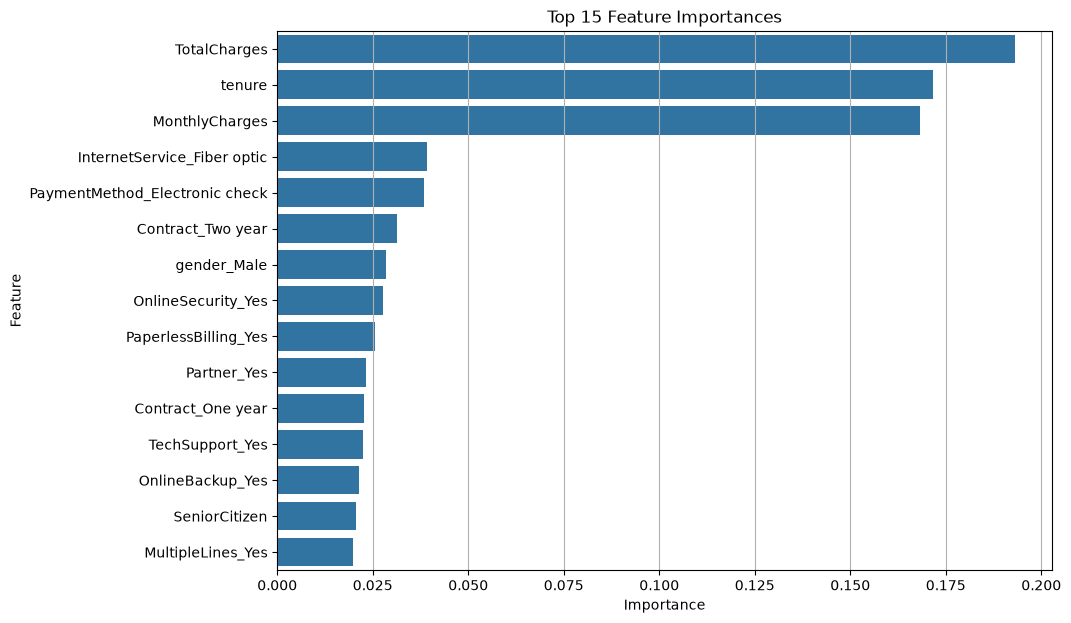

In [34]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x")

plt.savefig(
    "Screenshots/Task4_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 4 — Model Development Summary

The customer churn dataset was prepared by encoding categorical variables and converting the target variable into binary numerical values.

The dataset was divided into training and testing sets using an 80:20 ratio with stratified sampling.

A Random Forest Classifier containing 200 decision trees was selected because it can capture complex relationships between customer characteristics and churn behavior.

The model was successfully trained using the training dataset and used to generate predictions for unseen customers.

Feature importance was also analyzed to identify the customer characteristics that contributed most to the model's predictions.

The next step is to evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix.

# Task 5 — Model Evaluation & Final Results

## 1. Model Evaluation

The trained Random Forest model is evaluated using the unseen testing dataset.

Because customer churn is a binary classification problem, several evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Using multiple metrics provides a more complete understanding of model performance.


In [35]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 79.13%


## 2. Precision, Recall and F1-Score

### Precision

Precision measures how many of the customers predicted as churners actually churned.

A high precision means the model produces fewer false-positive churn predictions.

### Recall

Recall measures how many of the customers who actually churned were correctly identified by the model.

Recall is particularly important for churn prediction because failing to identify a customer who is likely to leave may result in a lost retention opportunity.

### F1-Score

The F1-score combines precision and recall into a single metric and is useful when both types of errors are important.

In [36]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Precision: 0.6361
Recall:    0.5000
F1-Score:  0.5599


In [37]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_results

,Metric,Score
0,Accuracy,0.791341
1,Precision,0.636054
2,Recall,0.500000
3,F1-Score,0.559880


## 3. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the classification model.

For this binary classification problem:

- **True Negative (TN):** Correctly predicted non-churn customer.
- **True Positive (TP):** Correctly predicted churn customer.
- **False Positive (FP):** Predicted churn but the customer did not churn.
- **False Negative (FN):** Predicted no churn but the customer actually churned.

The confusion matrix helps identify the types of errors made by the model.

In [38]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[928 107]
 [187 187]]


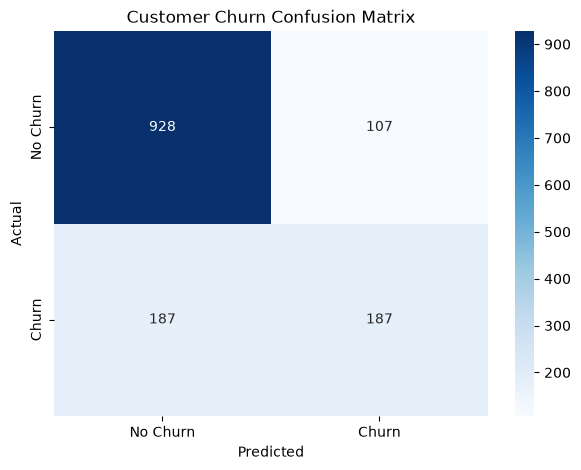

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "Screenshots/Task5_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Classification Report

The classification report provides precision, recall, F1-score, and support for both classes.

This provides a detailed view of how well the model identifies customers who churn and customers who remain with the company.

In [40]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 5. Incorrect Predictions

Incorrect predictions occur when the model's predicted class does not match the actual churn status.

Examining these cases can help us understand where the model struggles and whether certain types of customers are more difficult to classify.

In [41]:
incorrect_predictions = comparison_readable[
    comparison_readable["Actual"] != comparison_readable["Predicted"]
]

print(
    "Number of incorrect predictions:",
    len(incorrect_predictions)
)

incorrect_predictions.head(10)

Number of incorrect predictions: 294


,Actual,Predicted
1,No,Yes
9,Yes,No
17,No,Yes
26,Yes,No
39,Yes,No
41,No,Yes
42,No,Yes
49,Yes,No
61,Yes,No
64,Yes,No


## 6. Sample Predictions

The following examples compare the actual churn status with the prediction generated by the Random Forest model.

These examples demonstrate how the trained model performs on individual unseen customers.

In [42]:
sample_predictions = comparison_readable.head(10)

sample_predictions

,Actual,Predicted
0,No,No
1,No,Yes
2,No,No
3,No,No
4,No,No
5,No,No
6,No,No
7,No,No
8,No,No
9,Yes,No


## 7. Model Performance Visualization

The following chart compares the main evaluation metrics of the trained Random Forest model.

This provides a simple visual summary of the model's classification performance.

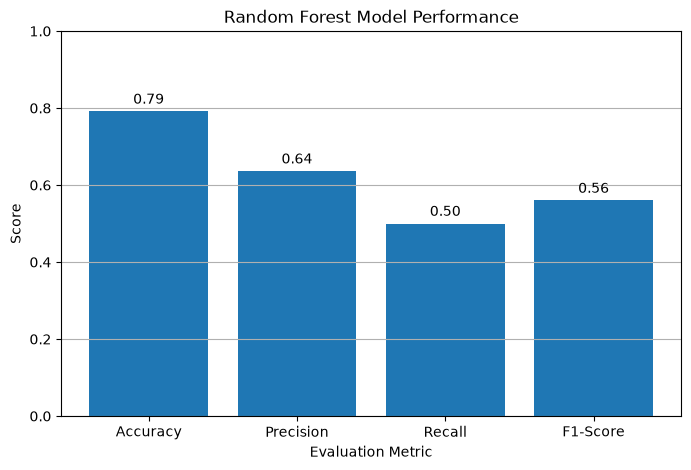

In [43]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.title("Random Forest Model Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

for i, value in enumerate(metrics.values()):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.grid(axis="y")

plt.savefig(
    "Screenshots/Task5_Model_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Business Interpretation

The customer churn prediction model can help businesses identify customers who may be at risk of leaving.

Customers predicted as likely to churn could be targeted with appropriate retention strategies, such as:

- Personalized offers
- Discounts
- Improved service plans
- Customer support follow-ups
- Contract incentives
- Loyalty programs

The model should be treated as a decision-support system rather than a replacement for human decision-making.

The most important evaluation metric may depend on the business objective. For example, if the company wants to identify as many potential churners as possible, recall may be prioritized. If retention campaigns are expensive, precision may become more important.

# Conclusion

This project successfully implemented a complete machine learning workflow for customer churn prediction.

The project began with the definition of a real-world customer retention problem and continued through data collection, data cleaning, exploratory data analysis, feature preprocessing, model development, training, prediction, and evaluation.

The Telco Customer Churn dataset was cleaned by handling missing values, removing duplicate records, and removing the customer identifier. Exploratory analysis was then performed to identify patterns related to customer churn.

A Random Forest Classifier was selected because of its ability to handle complex relationships and multiple features. The model was trained using an 80:20 training-testing split and used to predict churn for unseen customers.

The final model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics provide a comprehensive understanding of the model's predictive performance.

Overall, the project demonstrates how machine learning can be applied to a real-world business problem and how predictive models can support customer retention strategies.

# Future Scope

The project can be further improved through several approaches:

1. **Hyperparameter Tuning**  
   Grid Search or Randomized Search can be used to identify better Random Forest parameters.

2. **Model Comparison**  
   Other algorithms such as Logistic Regression, Decision Tree, KNN, Gradient Boosting, and XGBoost can be compared.

3. **Feature Engineering**  
   Additional meaningful features can be created from existing customer information.

4. **Class Imbalance Handling**  
   Techniques such as class weighting, oversampling, or SMOTE can be explored.

5. **Cross-Validation**  
   Cross-validation can provide a more reliable estimate of model performance.

6. **Explainable AI**  
   Techniques such as SHAP can be used to better explain individual predictions.

7. **Deployment**  
   The trained model can be deployed using Streamlit or another web application framework to provide real-time churn predictions.

8. **Continuous Learning**  
   New customer data can periodically be incorporated to retrain and improve the model.

# Final Project Summary

## Complete AI/ML Workflow

The final project followed the complete machine learning pipeline:

**Problem Definition**
↓  
**Data Collection**
↓  
**Data Cleaning**
↓  
**Data Preprocessing**
↓  
**Exploratory Data Analysis**
↓  
**Feature Selection**
↓  
**Train-Test Split**
↓  
**Random Forest Model**
↓  
**Model Training**
↓  
**Prediction**
↓  
**Evaluation**
↓  
**Business Interpretation**
↓  
**Conclusion**

The project demonstrates practical application of Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn to solve a real-world Artificial Intelligence problem.